## Data requirements for Udvary et al. (2022)

In [78]:
import Interface as I
from pathlib import Path
from getting_started import example_data_dir
import os

You can download the barrel cortex model from [Harvard Dataverse](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/JZPULN):

```shell
pixi run download_bc_model
```

In [79]:
# Check if the model is downloaded
from os.path import exists as path_exists, join as path_join, expandvars
assert path_exists(expandvars(path_join("$ISF_HOME", "barrel_cortex"))), "Please download the barrel cortex model first by running pixi r download_bc_model"

In [54]:
def print_head(fn, head=10):
    """Convenience function to print the first n lines of a file"""
    with open(fn) as input_file:
        head = [next(input_file) for _ in range(head)]
    print("".join(head))

The methods in [Udvary et al. (2022)](https://doi.org/10.1016/j.celrep.2022.110677) require the following empirical data:
- Amount of cells per cell type across the neuropil
- 3D density distribution of synapses across the neuropil
- Density of postsynaptic targets on the postsynaptic cell type, in units of length and area
- Locations of boutons in the neuropil, per cell type

The files that contain this data can be defined as default settings in the user configuration. Below, we inspect the content of each file to familiarize the user with the format of these data.

### Amount of cells per cell type across the neuropil

The file format is simply a `csv` file:

In [55]:
bc_data_dir = Path(example_data_dir).parent.parent / "barrel_cortex"
n_cells_fn = bc_data_dir / "nrCells.csv"

In [56]:
n_cells_df = I.pd.read_csv(n_cells_fn, sep="\t", index_col=0)
n_cells_df

,Alpha,A1,A2,A3,A4,Beta,B1,B2,B3,B4,...,C4,Delta,D1,D2,D3,D4,E1,E2,E3,E4
CELL TYPE,,,,,,,,,,,,,,,,,,,,,
L2,1684,1807,1733,1284,1108,1745,1897,2347,2016,2010,...,2539,2756,2416,3213,3545,3724,3765,4233,4300,3048
L34,2676,2724,2660,2070,1984,3739,3348,3736,3204,3684,...,5067,4769,4267,5701,5807,7071,5646,6178,6019,4674
L4py,489,502,516,341,355,699,646,730,598,630,...,900,915,820,1105,1061,1287,985,1040,1100,826
L4sp,1023,947,920,719,751,1190,1084,1096,1035,972,...,1191,1605,1437,1659,1493,1469,1774,2180,2004,1648
L4ss,1543,1387,1394,1085,1069,1964,1677,1655,1387,1449,...,1784,2517,2118,2452,2259,2107,2571,2784,3035,2294
L5st,958,1024,987,786,897,1149,1060,1170,1135,1384,...,1736,1790,1429,1851,1803,2122,2086,2373,2327,1930
L5tt,743,769,738,627,660,953,747,870,842,1042,...,1314,1420,1084,1484,1474,1606,1611,1843,1868,1502
L6cc,762,832,916,723,733,1007,850,962,917,1147,...,1549,1672,1227,1586,1592,1872,1988,2291,2191,1728
L6ccinv,439,436,469,393,453,555,468,494,483,640,...,894,971,689,891,912,1054,1170,1261,1195,1017


We see how the amount of cells across the neuropil is defined for each celltype (see the `"CELL TYPE"` index), and for each anatomical area. For the barrel cortex, that corresponds to individual columns, index from $[A-E][1-4]$ and $[\alpha-\delta]$.

In [57]:
n_cells = n_cells_df.sum().sum()
print(f"Counted {n_cells} cells in total")

Counted 536162 cells in total


The counting strategy for the data outlined above is described in [Oberlaender et al. (2009)](https://10.1016/j.jneumeth.2009.03.008)

Let's visualize the distribution of these cells across the barrel cortex:

In [58]:
%matplotlib inline
I.plt.style.use("fivethirtyeight")

def heatmap_cell_count(n_cells_df, cell_type):
    fig = I.plt.figure()
    n_cells_this_type = n_cells_df.loc[cell_type].drop(
        ["Alpha", "Beta", "Gamma", "Delta"]
    ).pipe(  # unravel index "A1-E4" into index A-E and columns 1-4
        lambda s: s.set_axis(
            I.pd.MultiIndex.from_arrays(arrays=[s.index.str[0], s.index.str[1].astype(int)])
        )
    ).unstack()

    I.sns.heatmap(
        data=n_cells_this_type,
    )
    I.plt.title(
        "Cell count for cell type: {}".format(cell_type)
    )
    I.plt.xlabel("Row")
    I.plt.ylabel("Column")
    return fig

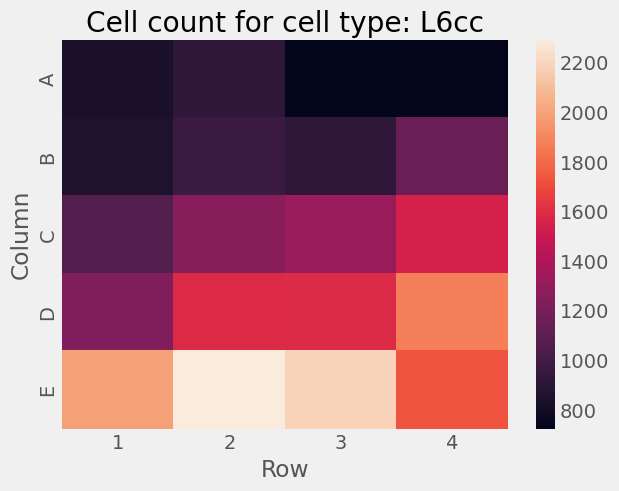

In [59]:
heatmap_cell_count(n_cells_df=n_cells_df, cell_type="L6cc");

### 3D density distribution of synapses across the neuropil

Let's check the file format again:

In [60]:
from singlecell_input_mapper.udvary2022.reader import read_scalar_field

pst_fn = str(bc_data_dir / "PST" / "EXNormalizationPSTs.am")
print_head(pst_fn, 25)

# AmiraMesh 3D ASCII 2.0


define Lattice 139 120 75

Parameters {
    Content "139x120x75 float, uniform coordinates",
    Spacing 50 50 50,
    QueryString "PSTWithCellTypesInSelection(neuron,XYZ,50.0000)",
    BoundingBox -3975 2925 -1725 4225 -2725 975,
    CoordType "uniform"
}

Lattice { float Data } @1

# Data section follows
@1
0.000000000000000e+00 
0.000000000000000e+00 
0.000000000000000e+00 
0.000000000000000e+00 
0.000000000000000e+00 
0.000000000000000e+00 
0.000000000000000e+00 
0.000000000000000e+00 



PST density fields are defined as AMIRA lattice files. These is simply a VTK-like definition of a 3D histogram.
You can read this in ISF as follows: 

In [61]:
sf = read_scalar_field(fname=pst_fn)
mesh = sf.mesh  
mesh.shape

(139, 120, 75)

You could visualize this 3D density field in `matplotlib`. However, it it better suited to use dedicated 3D visualization software, as `matplotlib`s 3D capabilities are somewhat limited. For example, you can export this mesh to `VTK` to visualize it in e.g. ParaView:

In [62]:
from visualize.vtk import convert_amira_lattice_to_vtk

convert_amira_lattice_to_vtk(
    pst_fn,
    outname="exc_pst"
)

After some processing, you can inspect the 3D density as 3D isosurfaces:

<img src="../../../docs/_static/_images/exPST.png" alt="Excitatory PSTs"  width="60%" />

### Density of postsynaptic targets, in units of dendrite length or membrane area

This is again a simple `csv` file:

In [63]:
conn_df = I.pd.read_csv(
    bc_data_dir / "ConnectionsV8.csv",
    sep="\t"
)
conn_df.head(12)

,PRESYNAPTIC_CELLTYPE,POSTSYNAPTIC_CELLTYPE,LENGTH_DENSITY_SOMA,LENGTH_DENSITY_APICAL,LENGTH_DENSITY_BASAL,AREA_DENSITY_SOMA,AREA_DENSITY_APICAL,AREA_DENSITY_BASAL
0,ALL_EXCITATORY,L2,0,1.68,1.68,0.00,0.00,0.00
1,ALL_EXCITATORY,L34,0,1.68,1.68,0.00,0.00,0.00
2,ALL_EXCITATORY,L4py,0,1.68,1.17,0.00,0.00,0.00
3,ALL_EXCITATORY,L4sp,0,1.17,1.17,0.00,0.00,0.00
4,ALL_EXCITATORY,L4ss,0,1.17,1.17,0.00,0.00,0.00
5,ALL_EXCITATORY,L5st,0,1.68,1.04,0.00,0.00,0.00
6,ALL_EXCITATORY,L5tt,0,1.68,1.04,0.00,0.00,0.00
7,ALL_EXCITATORY,L6cc,0,1.04,1.04,0.00,0.00,0.00
8,ALL_EXCITATORY,L6ccinv,0,1.04,1.04,0.00,0.00,0.00
9,ALL_EXCITATORY,L6ct,0,1.04,1.04,0.00,0.00,0.00


We can see that e.g. excitatory neurons range from $1.04$ to $1.68$ spines per $\mu m$ dendritic length. 
For example:


In [64]:
post_ct = "L2"
conn_df[conn_df['POSTSYNAPTIC_CELLTYPE'] == post_ct]

,PRESYNAPTIC_CELLTYPE,POSTSYNAPTIC_CELLTYPE,LENGTH_DENSITY_SOMA,LENGTH_DENSITY_APICAL,LENGTH_DENSITY_BASAL,AREA_DENSITY_SOMA,AREA_DENSITY_APICAL,AREA_DENSITY_BASAL
0,ALL_EXCITATORY,L2,0,1.68,1.68,0.00,0.00,0.00
10,ALL_INHIBITORY,L2,0,0.00,0.00,0.03,0.03,0.03


This means that we can expect about $1.68$ excitatory PSTs per $\mu m$ of L2 apical dendrite, and $0.03$ inhibitory PSTs per $\mu m^2$ of L2 soma membrane.
More info for how these values were calculated can be found in [Udvary et al. (2022)](https://doi.org/10.1016/j.celrep.2022.110677)

### Locations of boutons in the neuropil, per cell type

In [65]:
boutons_dir = bc_data_dir / "singleaxon_boutons_ascii"
I.os.listdir(boutons_dir)

['C2',
 'E1',
 'E4',
 'B2',
 'D1',
 'D4',
 'A4',
 'Delta',
 'A2',
 'C1',
 'C4',
 'Beta',
 'E3',
 'B1',
 'B4',
 'Alpha',
 'D3',
 'A1',
 'C3',
 'Gamma',
 'E2',
 'B3',
 'D2',
 'A3']

We see that the locations of boutons are organized per anatomical area. For the barrel cortex, that means per column. Let's inspect a single column.

In [66]:
boutons_c2_dir = boutons_dir / "C2"
I.os.listdir(boutons_c2_dir)

['SymLocal1',
 'L45Sym',
 'L34',
 'SymLocal2',
 'L45Peak',
 'L5st',
 'L6cc',
 'L5tt',
 'L6ccinv',
 'SymLocal6',
 'L4ss',
 'SymLocal3',
 'L1',
 'VPM',
 'SymLocal4',
 'L4py',
 'L6ct',
 'L23Trans',
 'L4sp',
 'L2',
 'L56Trans',
 'SymLocal5']

Here, they are again organized per cell type.

In [67]:
cell_type = "L6cc"
ct_dir = boutons_c2_dir / cell_type
I.os.listdir(ct_dir)

['L6ccaxon1boutonsC2.am',
 'L6ccaxon4boutonsC2.am',
 'L6ccaxon2boutonsC2.am',
 'L6ccaxon0boutonsC2.am',
 'L6ccaxon3boutonsC2.am',
 'L6ccaxon5boutonsC2.am']

Finally, we see the actual data files. Let's inspect one of them:

In [68]:
boutons_fn = [e for e in ct_dir.glob("*.am")][0]
print_head(boutons_fn, 25)

# AmiraMesh 3D ASCII 2.0


define Lattice 39 34 42

Parameters {
    Content "39x34x42 float, uniform coordinates",
    Spacing 50 50 50,
    QueryString "boutons(axon WHERE (CellTypeIs('L6ccaxon1') AND PrimaryColumnIs('C2')),XYZ,50.0000)",
    BoundingBox -925 975 -375 1275 -1475 575,
    CoordType "uniform"
}

Lattice { float Data } @1

# Data section follows
@1
0.000000000000000e+00 
0.000000000000000e+00 
0.000000000000000e+00 
0.000000000000000e+00 
0.000000000000000e+00 
0.000000000000000e+00 
0.000000000000000e+00 
0.000000000000000e+00 



This is again an AMIRA mesh file. We can visualize like before:

In [69]:
convert_amira_lattice_to_vtk(
    boutons_fn,
    "boutons"
)

<img src="../../../docs/_static/_images/boutons.png" alt="Boutons"  width="80%" />

This shows a bouton density for a cell type, located at some anatomical area in the neuropil (in this case: a L6cc in the C2 column).

We can also project onto an axis:

Text(26.78333333333333, 0.5, 'Z')

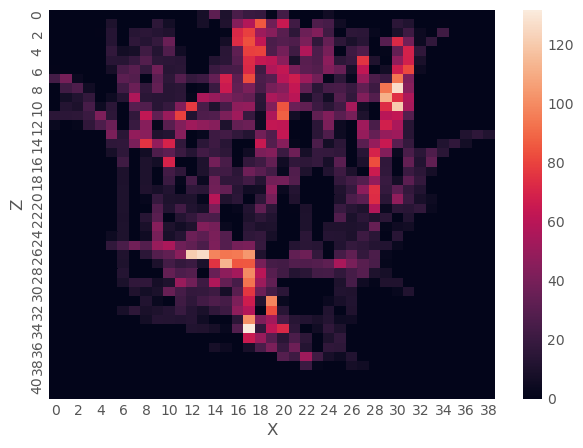

In [75]:
sf = read_scalar_field(str(boutons_fn))

proj_axis = 1
projection = I.np.sum(
    sf.mesh,
    axis=proj_axis
)

I.sns.heatmap(
    I.np.flip(projection.T, 0)
)
I.plt.xlabel("X")
I.plt.ylabel("Z")

### Additional data: representative soma locations

We can visualize a sample of these soma locations to get a sense of our network model.

In [71]:
anatomy_dir = I.os.path.join(example_data_dir, 'anatomical_constraints')

landmarks = []
cell_types = []

somata = I.pd.read_csv(
    I.os.path.join(anatomy_dir, "presynaptic_somata_soma_locations.csv"), 
    skiprows=[0,1,2,3],
    header=None,
    delimiter="\t",
    names=['Type', 'cell ID', 'x', 'y', 'z']
    )
somata[['cell_type', 'column']] = somata['Type'].str.split('_', n=1, expand=True)
somata

,Type,cell ID,x,y,z,cell_type,column
0,L45Peak_D1,0,-626.213,20.344,-58.270,L45Peak,D1
1,L45Peak_D1,1,-320.834,13.905,-248.013,L45Peak,D1
2,L45Peak_D1,2,-471.762,100.233,-114.434,L45Peak,D1
3,L45Peak_D1,3,-423.770,94.010,-156.002,L45Peak,D1
4,L45Peak_D1,4,-294.765,145.499,-241.157,L45Peak,D1
...,...,...,...,...,...,...,...
19699,L34_D3,292,485.718,83.024,122.828,L34,D3
19700,L34_D3,293,483.525,-213.608,190.240,L34,D3
19701,L34_D3,294,586.649,-160.437,98.395,L34,D3
19702,L34_D3,295,275.697,189.550,319.151,L34,D3


In [72]:
I.plt.style.use('ggplot')

#### Plot per cell type

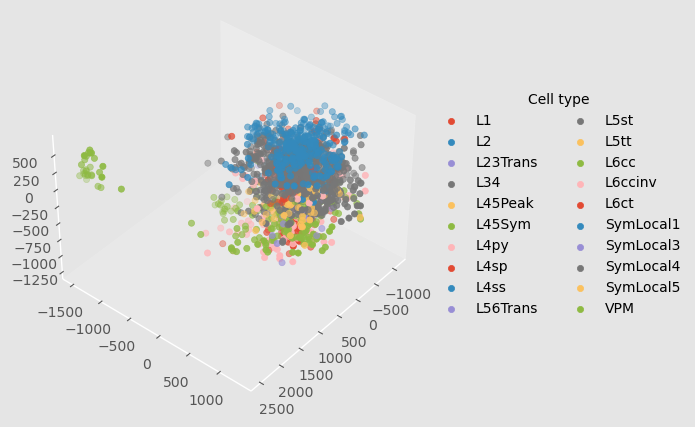

In [73]:
%matplotlib inline

fig = I.plt.figure()
ax = fig.add_subplot(projection='3d')
fig.patch.set_facecolor(ax.get_facecolor())
ax.view_init(azim=40, elev=40)
ax.grid(False)

for cell_type, pts in somata.sample(2000).groupby("cell_type"):
    x, y, z = pts[["x", "y", "z"]].values.T
    ax.scatter(
        x, y, z,
        label=cell_type)

ax.legend(
    bbox_to_anchor=(1, 0.5), 
    loc='center left', 
    frameon=False, 
    ncol=2,
    title="Cell type")
I.plt.show()

#### Plot per column

Since the barrel cortex is well-organized into recognizable columns, we can colorize the cells based on which column they belong to:

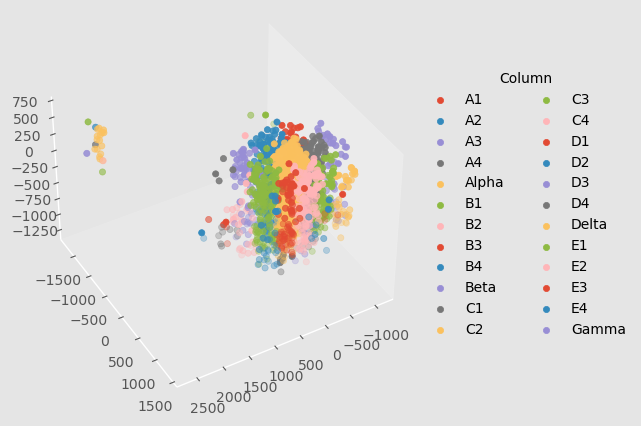

In [74]:
fig = I.plt.figure()
ax = fig.add_subplot(projection='3d')
fig.patch.set_facecolor(ax.get_facecolor())
ax.view_init(azim=60, elev=40)
ax.grid(False)

for column, pts in somata.sample(2000).groupby("column"):
    x, y, z = pts[["x", "y", "z"]].values.T
    ax.scatter(
        x, y, z, 
        label=column)

ax.legend(
    bbox_to_anchor=(1, 0.5), 
    loc='center left', 
    frameon=False, 
    ncol=2,
    title="Column")
I.plt.show()